# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos 'df_furniture.csv'
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus ultimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay seasonality. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Cargamos los datos

In [44]:
furniture = pd.read_csv('data/df_furniture.csv')
furniture.head()

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618


In [45]:
furniture.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     331 non-null    object 
 1   furniture_price_adjusted  331 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.3+ KB


## 2. Tratar la fecha como texto y parsear

In [46]:
furniture["year"] = furniture["Month"].str.slice(0, 4)
furniture["month"] = furniture["Month"].str.slice(5, 7)
furniture["day"] = "01"   # día fijo

In [47]:
furniture[["year", "month", "day"]] = furniture[["year", "month", "day"]].apply(
    pd.to_numeric, errors="coerce"
)

In [48]:
furniture["date"] = pd.to_datetime(
    furniture[["year", "month", "day"]],
    errors="coerce"
)

In [49]:
furniture.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Month                     331 non-null    object        
 1   furniture_price_adjusted  331 non-null    float64       
 2   year                      331 non-null    int64         
 3   month                     331 non-null    int64         
 4   day                       331 non-null    int64         
 5   date                      331 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 15.6+ KB


## 3. ¿De qué fecha a qué fecha va el histórico?

In [50]:
furniture["date"].min(), furniture["date"].max()

(Timestamp('1992-01-01 00:00:00'), Timestamp('2019-07-01 00:00:00'))

## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

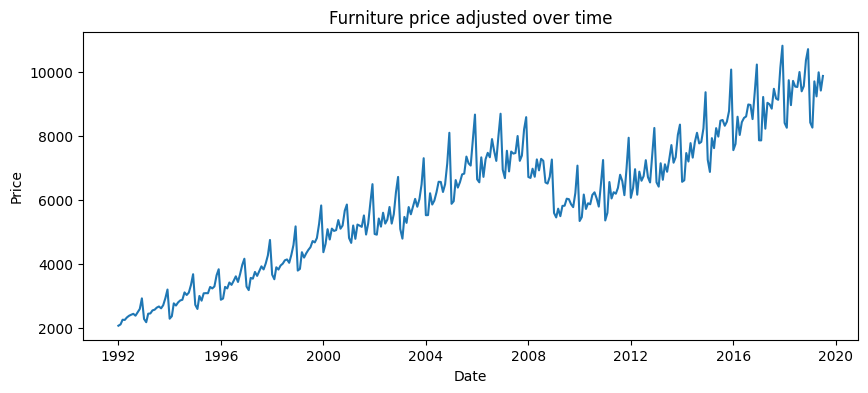

In [51]:
plt.figure(figsize=(10,4))
plt.plot(furniture["date"], furniture["furniture_price_adjusted"])
plt.title("Furniture price adjusted over time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


<Axes: xlabel='month'>

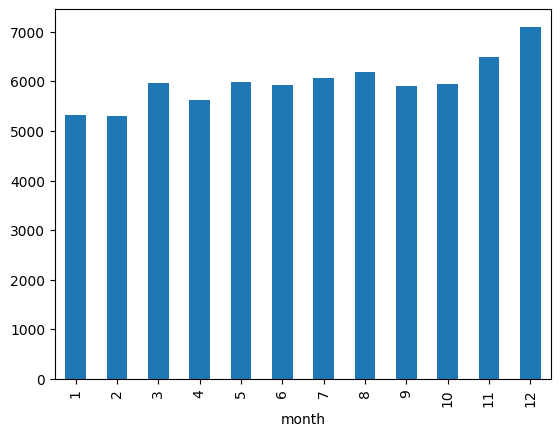

In [52]:
furniture["month"] = furniture["date"].dt.month
furniture.groupby("month")["furniture_price_adjusted"].mean().plot(kind="bar")

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?

In [53]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(furniture["furniture_price_adjusted"].dropna())

#print("ADF Statistic:", result[0])
print("p-value:", result[1])


p-value: 0.7035529748089981


window no hace falta ponerlo, está por defecto

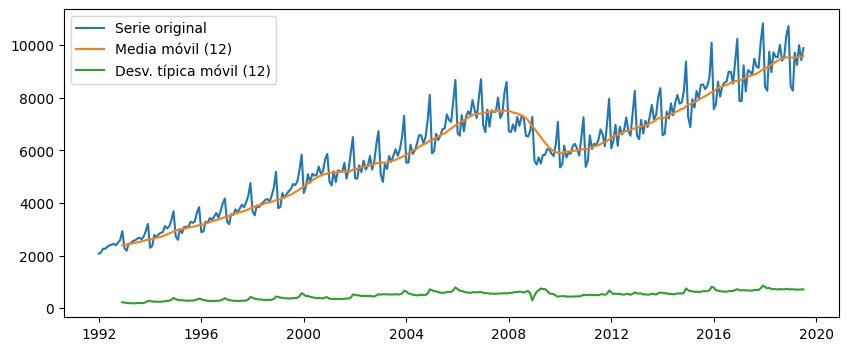

In [54]:
rolling_mean = furniture["furniture_price_adjusted"].rolling(window=12).mean()
rolling_std = furniture["furniture_price_adjusted"].rolling(window=12).std()

plt.figure(figsize=(10,4))
plt.plot(furniture["date"], furniture["furniture_price_adjusted"], label="Serie original")
plt.plot(furniture["date"], rolling_mean, label="Media móvil (12)")
plt.plot(furniture["date"], rolling_std, label="Desv. típica móvil (12)")
plt.legend()
plt.show()

Se ve una tendencia creciente a lo largo del tiempo y el p.value > 0.05 demuestra que no hay estacionalidad

## 6. ¿Conoces algún método para representar mejor la tendencia?

NO

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

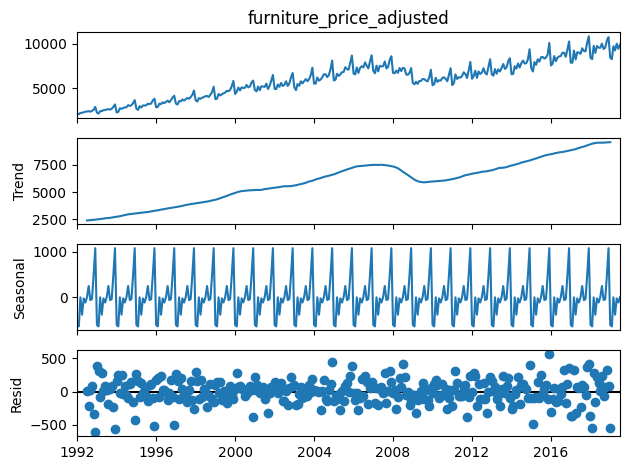

In [55]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

series = furniture.set_index("date")["furniture_price_adjusted"]

decomp = seasonal_decompose(series, model="additive", period=12)

decomp.plot()
plt.show()

Más robusto según ChatGPT

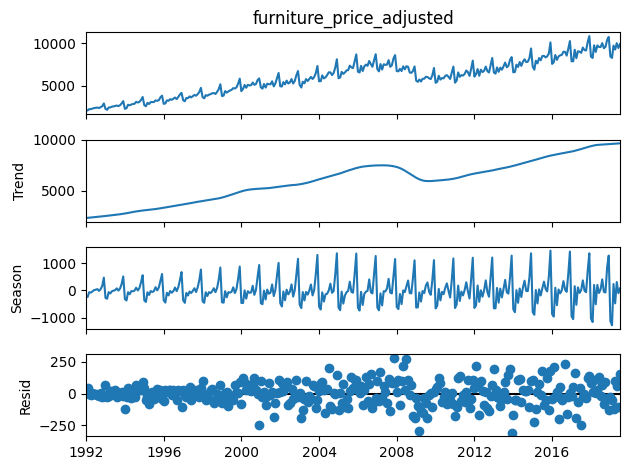

In [56]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

series = furniture.set_index("date")["furniture_price_adjusted"]

stl = STL(series, period=12)
res = stl.fit()

res.plot()
plt.show()


## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

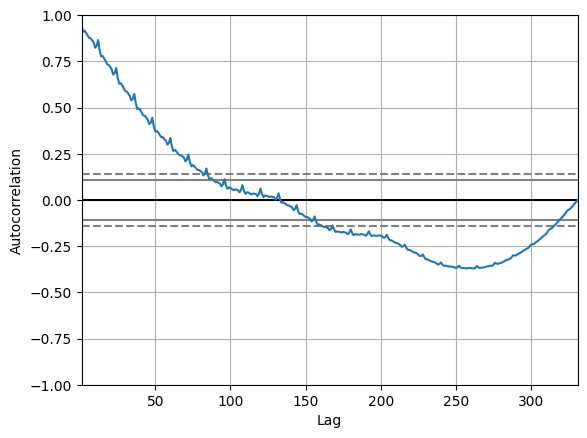

In [57]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(furniture.furniture_price_adjusted.values);

<Figure size 800x400 with 0 Axes>

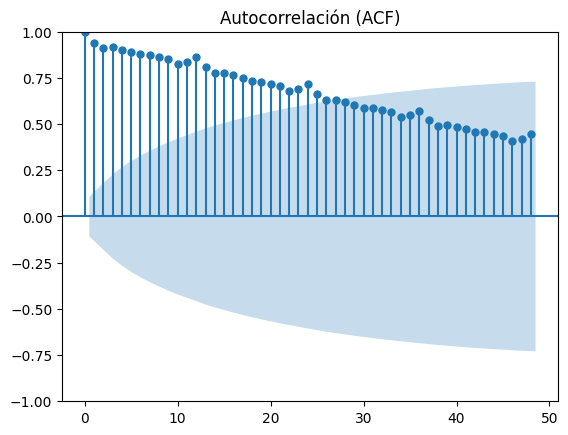

In [58]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

series = series.dropna()  # la serie mensual que ya usabas

plt.figure(figsize=(8,4))
plot_acf(series, lags=48)
plt.title("Autocorrelación (ACF)")
plt.show()


## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

In [59]:
import pandas as pd

df_lags = pd.DataFrame({"y": series})

for i in range(1, 6):
    df_lags[f"lag_{i}"] = df_lags["y"].shift(i)

df_lags = df_lags.dropna()

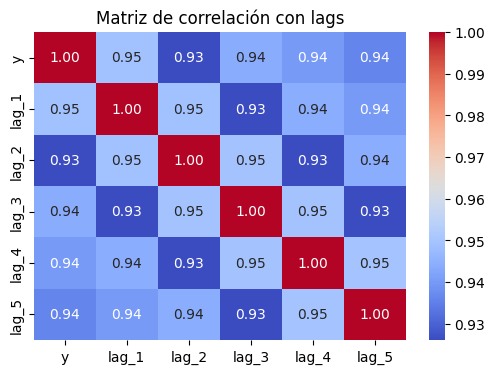

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    df_lags.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación con lags")
plt.show()


## 10. Ya hemos visto que hay seasonality. ¿Cada cuántos instantes se cumple ese patrón?

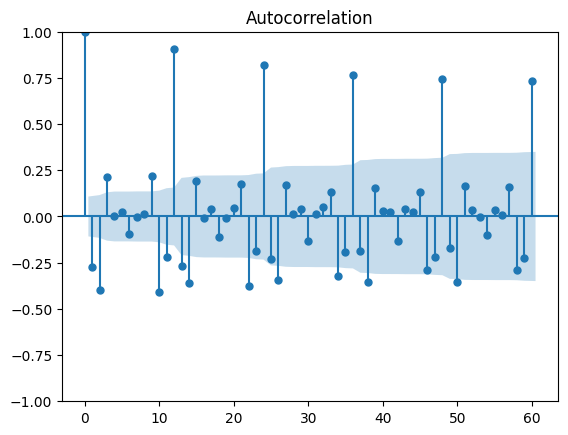

In [65]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

x = series.diff().dropna()   # elimina tendencia (aprox)
plot_acf(x, lags=60)
plt.show()

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [62]:
series_d1 = series.diff().dropna()

In [63]:
series_ds = series.diff(12).dropna()

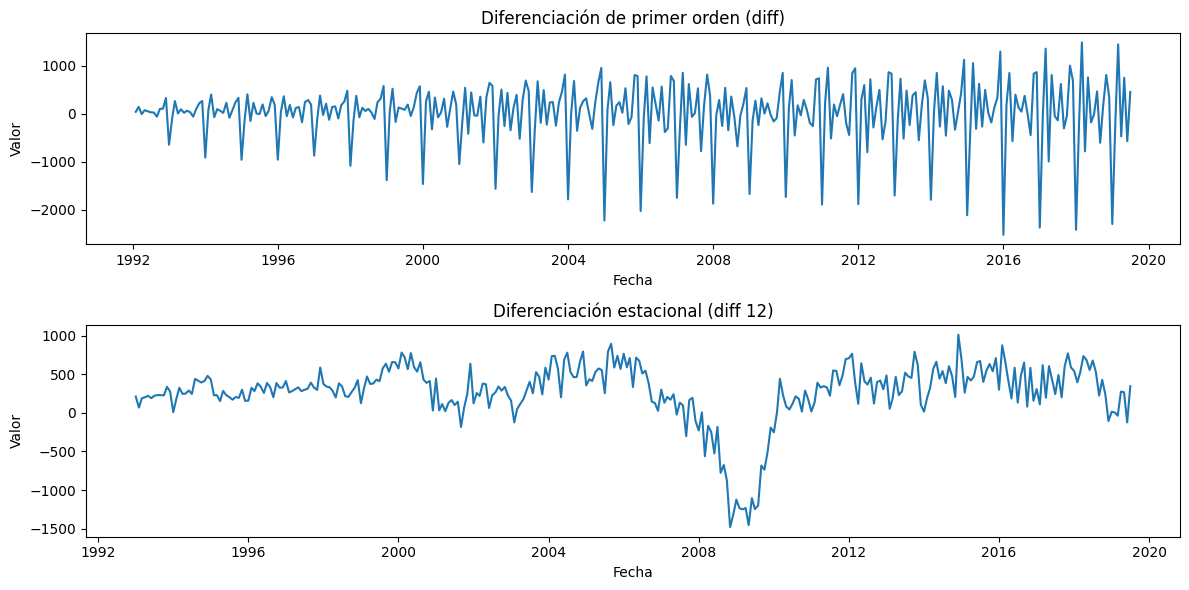

In [66]:
# Gráficas
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(series_d1)
plt.title("Diferenciación de primer orden (diff)")
plt.xlabel("Fecha")
plt.ylabel("Valor")

plt.subplot(2, 1, 2)
plt.plot(series_ds)
plt.title("Diferenciación estacional (diff 12)")
plt.xlabel("Fecha")
plt.ylabel("Valor")

plt.tight_layout()
plt.show()
